In [12]:
# 安装额外的库
!pip install statsmodels filterpy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import json
import os

# 新增导入
from statsmodels.tsa.seasonal import seasonal_decompose
from filterpy.kalman import KalmanFilter # filterpy库中的KalmanFilter

# 设置设备 (GPU 或 CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- Environment Setup ---")
print(f"Using device: {device}")
print(f"PyTorch Version: {torch.__version__}")
if torch.cuda.is_available():
    print(f"CUDA available. GPU: {torch.cuda.get_device_name(0)}")
    print(f"PyTorch built with CUDA version: {torch.version.cuda}")
else:
    print("CUDA not available. Running on CPU.")

import sympy
print(f"Sympy Version: {sympy.__version__}") # 确保 sympy 已正确加载
print(f"--- Setup Complete ---")

--- Environment Setup ---
Using device: cuda
PyTorch Version: 2.5.1+cu124
CUDA available. GPU: Tesla T4
PyTorch built with CUDA version: 12.4
Sympy Version: 1.13.1
--- Setup Complete ---


In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
print(f"\n--- Data Loading and Initial Labeling ---")
DATA_FILE_COLAB_PATH = '/content/drive/MyDrive/data/realAdExchange/exchange-3_cpc_results.csv'
LABEL_FILE_COLAB_PATH = '/content/drive/MyDrive/labels/combined_windows.json'
JSON_KEY_FOR_LABELS = 'realAdExchange/exchange-3_cpc_results.csv'

data_df = None
try:
    data_df = pd.read_csv(DATA_FILE_COLAB_PATH)
    print(f"Successfully loaded data from: {DATA_FILE_COLAB_PATH}")
    data_df['timestamp'] = pd.to_datetime(data_df['timestamp'])
    data_df = data_df.set_index('timestamp')
    print("Timestamp column processed and set as index.")
except Exception as e:
    print(f"Error during data loading or initial timestamp processing: {e}")

if data_df is not None:
    data_df['is_anomaly'] = 0
    parsed_anomaly_windows_count_initial = 0
    try:
        with open(LABEL_FILE_COLAB_PATH, 'r') as f:
            all_labels_json = json.load(f)
        raw_anomaly_windows_list = all_labels_json.get(JSON_KEY_FOR_LABELS, [])
        if raw_anomaly_windows_list:
            for window_event in raw_anomaly_windows_list:
                if isinstance(window_event, list) and len(window_event) == 2:
                    try:
                        start_ts = pd.to_datetime(window_event[0])
                        end_ts = pd.to_datetime(window_event[1])
                        anomalous_points_mask = (data_df.index >= start_ts) & (data_df.index <= end_ts)
                        data_df.loc[anomalous_points_mask, 'is_anomaly'] = 1
                        if anomalous_points_mask.sum() > 0:
                            parsed_anomaly_windows_count_initial += 1
                    except Exception as e_win:
                        print(f"  Warning: Could not process window event {window_event} for initial labeling: {e_win}")
            print(f"Initial label processing complete. Processed {parsed_anomaly_windows_count_initial} anomaly window(s).")
            print(f"Total data points initially marked as anomalous in data_df: {data_df['is_anomaly'].sum()}")
        else:
            print(f"No anomaly windows found for key '{JSON_KEY_FOR_LABELS}' for initial labeling.")
    except Exception as e_label:
        print(f"An error occurred during initial label processing: {e_label}")
else:
    print("data_df was not loaded successfully. Cannot proceed.")

print(f"--- Data Loading and Initial Labeling Complete ---")


--- Data Loading and Initial Labeling ---
Successfully loaded data from: /content/drive/MyDrive/data/realAdExchange/exchange-3_cpc_results.csv
Timestamp column processed and set as index.
Initial label processing complete. Processed 3 anomaly window(s).
Total data points initially marked as anomalous in data_df: 153
--- Data Loading and Initial Labeling Complete ---



--- Differencing Preprocessing and Label Alignment ---
Applying 1-order Differencing.
Differencing complete. Original length: 1538, Differenced length (after dropna): 1537
Differenced data head:
 timestamp
2011-07-01 01:15:01   -0.034670
2011-07-01 02:15:01    0.009955
2011-07-01 03:15:01   -0.000312
2011-07-01 04:15:01    0.000283
2011-07-01 05:15:01    0.000273
Name: value, dtype: float64


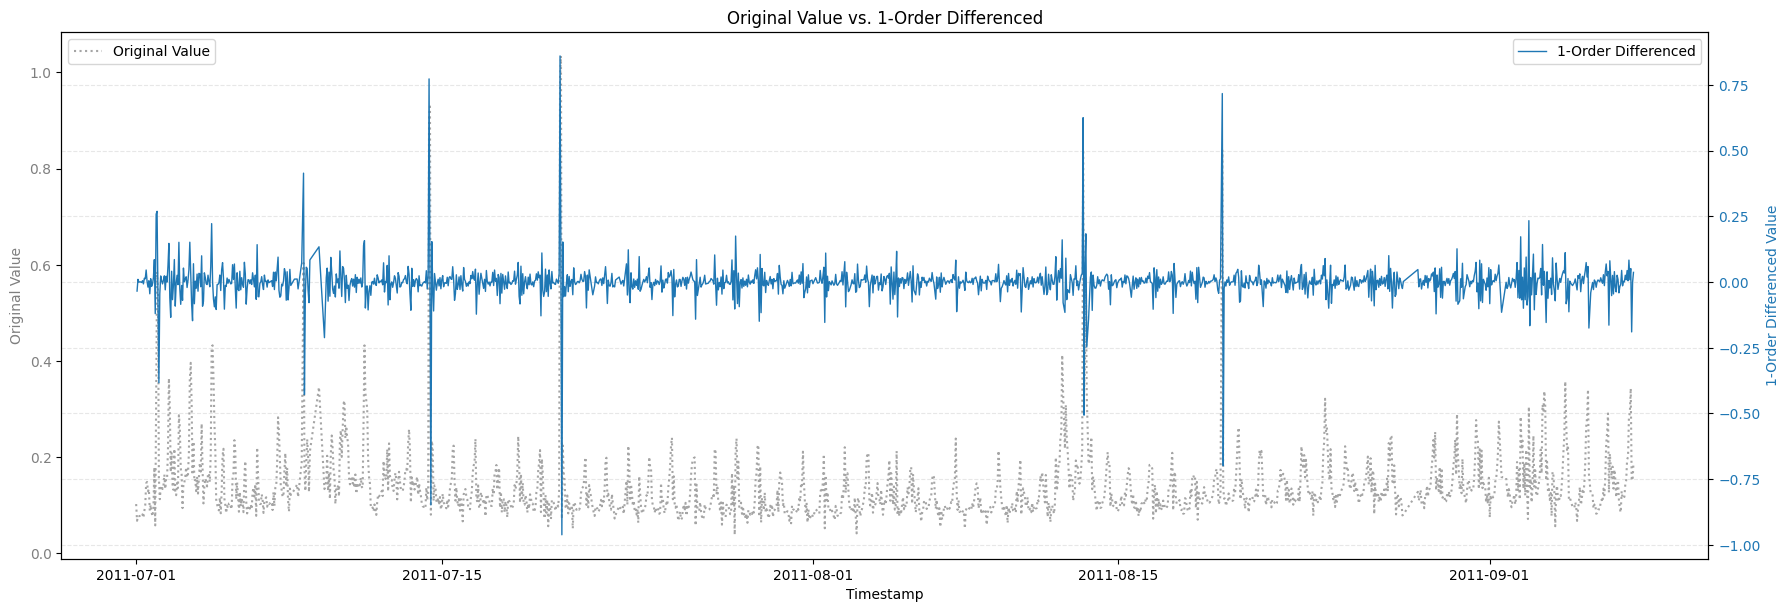

Shape of time_series_for_lstm_raw (Diff): (1537, 1)
Shape of true_labels_for_evaluation_aligned (Diff): (1537,)
Sum of anomalies in aligned labels (Diff): 153
--- Differencing Preprocessing and Label Alignment Complete ---


In [15]:
print(f"\n--- Differencing Preprocessing and Label Alignment ---")
time_series_for_lstm_raw = None
true_labels_for_evaluation_aligned = None
processed_series_index = None # 用于存储差分后序列的索引，方便后续可视化对齐

if data_df is not None and 'value' in data_df.columns:
    DIFFERENCING_ORDER = 1  # <<< 你可以调整这个差分阶数，例如 1 (一阶差分) 或 2 (二阶差分)
    print(f"Applying {DIFFERENCING_ORDER}-order Differencing.")

    # 1. 应用差分
    series_diff = data_df['value'].copy() # 使用副本以避免修改原始data_df['value']
    for i in range(DIFFERENCING_ORDER):
        series_diff = series_diff.diff(periods=1) # 每次应用一阶差分

    # 2. 处理差分操作在开头产生的NaN值，通常直接删除
    series_diff_processed = series_diff.dropna()
    processed_series_index = series_diff_processed.index # 保存处理后序列的有效时间戳索引

    print(f"Differencing complete. Original length: {len(data_df['value'])}, Differenced length (after dropna): {len(series_diff_processed)}")
    if not series_diff_processed.empty:
        print("Differenced data head:\n", series_diff_processed.head())

        # 可选：绘制原始序列 vs 差分后序列
        fig, ax1 = plt.subplots(figsize=(18, 6))
        color = 'tab:grey'
        ax1.set_xlabel('Timestamp')
        ax1.set_ylabel('Original Value', color=color)
        ax1.plot(data_df.index, data_df['value'], color=color, alpha=0.7, linestyle=':', label='Original Value')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.legend(loc='upper left')

        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel(f'{DIFFERENCING_ORDER}-Order Differenced Value', color=color)
        ax2.plot(series_diff_processed.index, series_diff_processed, color=color, linewidth=1, label=f'{DIFFERENCING_ORDER}-Order Differenced')
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.legend(loc='upper right')

        fig.tight_layout()
        plt.title(f"Original Value vs. {DIFFERENCING_ORDER}-Order Differenced")
        plt.grid(True, linestyle='--', alpha=0.3)
        plt.show()

        # 3. 准备用于LSTM的序列
        time_series_for_lstm_raw = series_diff_processed.values.reshape(-1, 1)

        # 4. 对齐真实异常标签
        # 由于差分后删除了开头的NaN，序列变短，标签必须与保留下来的processed_series_index对齐
        if 'is_anomaly' in data_df.columns and processed_series_index is not None and not processed_series_index.empty:
            true_labels_for_evaluation_aligned = data_df['is_anomaly'].loc[processed_series_index].to_numpy()
            print(f"Shape of time_series_for_lstm_raw (Diff): {time_series_for_lstm_raw.shape}")
            print(f"Shape of true_labels_for_evaluation_aligned (Diff): {true_labels_for_evaluation_aligned.shape}")
            print(f"Sum of anomalies in aligned labels (Diff): {true_labels_for_evaluation_aligned.sum()}")
        elif len(time_series_for_lstm_raw) > 0: # 如果差分序列不为空但标签对齐失败
            print("Warning: Could not align 'is_anomaly' labels with differenced series. Using all zeros for labels.")
            true_labels_for_evaluation_aligned = np.zeros(len(time_series_for_lstm_raw), dtype=int)
        else: # 如果差分序列为空
             true_labels_for_evaluation_aligned = np.array([], dtype=int)


    else: # series_diff_processed 为空 (可能差分阶数过高或原始数据太短)
        print("Differenced series is empty. Cannot proceed with LSTM.")
        time_series_for_lstm_raw = np.array([]).reshape(-1,1) # 设置为空数组
        true_labels_for_evaluation_aligned = np.array([], dtype=int)


else:
    print("data_df or 'value' column not available for Differencing preprocessing.")

print(f"--- Differencing Preprocessing and Label Alignment Complete ---")

In [16]:
print(f"\n--- LSTM Data Preprocessing (on Differenced Output) ---")
# 确保 time_series_for_lstm_raw 和 true_labels_for_evaluation_aligned 已成功生成且不为空
if ('time_series_for_lstm_raw' in locals() and time_series_for_lstm_raw is not None and
    'true_labels_for_evaluation_aligned' in locals() and true_labels_for_evaluation_aligned is not None and
    len(time_series_for_lstm_raw) > 0): # 增加长度检查

    scaler = MinMaxScaler(feature_range=(-1, 1))
    time_series_scaled = scaler.fit_transform(time_series_for_lstm_raw) # 使用差分处理后的数据
    print(f"Data scaled. Shape: {time_series_scaled.shape}")

    SEQUENCE_LENGTH = 30 # 确保序列长度不大于 time_series_scaled 的长度
    if len(time_series_scaled) < SEQUENCE_LENGTH:
        print(f"Warning: Length of scaled data ({len(time_series_scaled)}) is less than SEQUENCE_LENGTH ({SEQUENCE_LENGTH}). Adjust SEQUENCE_LENGTH or check preprocessing.")
        #  可以考虑在此处停止或调整SEQUENCE_LENGTH
        #  SEQUENCE_LENGTH = len(time_series_scaled) -1 # 作为一个例子，但不一定好

    def create_sequences_colab(input_data, sequence_length):
        sequences = []
        # 确保可以创建至少一个序列
        if len(input_data) >= sequence_length:
            for i in range(len(input_data) - sequence_length + 1):
                seq = input_data[i:(i + sequence_length)]
                sequences.append(seq)
        else:
            print(f"Cannot create sequences: input data length ({len(input_data)}) is less than sequence length ({sequence_length}).")
        return np.array(sequences)

    X_sequences = create_sequences_colab(time_series_scaled, SEQUENCE_LENGTH)

    if X_sequences.shape[0] > 0: # 确保成功创建了序列
        X_tensor = torch.tensor(X_sequences, dtype=torch.float32).to(device)
        y_tensor = torch.tensor(X_sequences, dtype=torch.float32).to(device) # 自编码器的目标是输入本身

        print(f"Created sequences. X_tensor shape: {X_tensor.shape}, y_tensor shape: {y_tensor.shape}")

        BATCH_SIZE = 32
        dataset = TensorDataset(X_tensor, y_tensor)
        dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
        print(f"DataLoader created with batch size {BATCH_SIZE}.")
    else:
        print("No sequences were created. DataLoader cannot be initialized. Check SEQUENCE_LENGTH and data length.")
        # 将 dataloader 设置为 None 或其他标记，以便后续步骤可以跳过
        dataloader = None
else:
    print("Skipping LSTM data preprocessing as input data from Differencing step is not available or empty.")
    dataloader = None # 确保 dataloader 在此路径下也被定义（为None）

print(f"--- LSTM Data Preprocessing Complete ---")


--- LSTM Data Preprocessing (on Differenced Output) ---
Data scaled. Shape: (1537, 1)
Created sequences. X_tensor shape: torch.Size([1508, 30, 1]), y_tensor shape: torch.Size([1508, 30, 1])
DataLoader created with batch size 32.
--- LSTM Data Preprocessing Complete ---


In [17]:
print(f"\n--- LSTM Autoencoder Model Definition ---")
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers):
        super(LSTMAutoencoder, self).__init__()
        self.encoder_lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.decoder_lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim, # 可以选择不同的解码器隐藏层大小
            num_layers=num_layers,
            batch_first=True
        )
        self.output_layer = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_dim)
        encoder_outputs, (hidden, cell) = self.encoder_lstm(x)
        # 使用编码器的输出（所有时间步）作为解码器的输入
        decoder_outputs, _ = self.decoder_lstm(encoder_outputs, (hidden, cell))
        reconstructed_x = self.output_layer(decoder_outputs)
        return reconstructed_x

# 模型参数
INPUT_DIM = 1  # 单变量时间序列
HIDDEN_DIM = 64 # LSTM隐藏单元数量 (可调)
NUM_LAYERS = 2  # LSTM层数 (可调)

if 'X_tensor' in locals(): # 确保模型可以被实例化
    model = LSTMAutoencoder(INPUT_DIM, HIDDEN_DIM, NUM_LAYERS).to(device)
    print(model)
    print(f"Model instantiated and moved to device: {next(model.parameters()).device}")
else:
    print("Cannot instantiate model as X_tensor is not available.")
print(f"--- Model Definition Complete ---")


--- LSTM Autoencoder Model Definition ---
LSTMAutoencoder(
  (encoder_lstm): LSTM(1, 64, num_layers=2, batch_first=True)
  (decoder_lstm): LSTM(64, 64, num_layers=2, batch_first=True)
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
)
Model instantiated and moved to device: cuda:0
--- Model Definition Complete ---



--- Model Training ---
Starting training for 30 epochs...
Epoch [5/30], Loss: 0.006298
Epoch [10/30], Loss: 0.006252
Epoch [15/30], Loss: 0.000115
Epoch [20/30], Loss: 0.000012
Epoch [25/30], Loss: 0.000007
Epoch [30/30], Loss: 0.000005
Training finished.


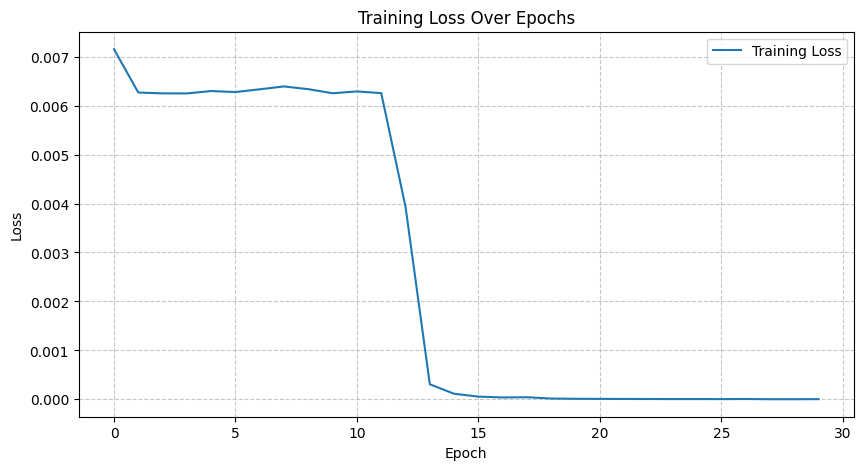

--- Model Training Complete ---


In [18]:
print(f"\n--- Model Training ---")
if 'model' in locals() and 'dataloader' in locals(): # 确保模型和数据加载器已准备好
    NUM_EPOCHS = 30  # 可根据需要调整
    LEARNING_RATE = 0.001

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE) # 之前本地环境出错的地方

    history = {'train_loss': []}
    print(f"Starting training for {NUM_EPOCHS} epochs...")
    for epoch in range(NUM_EPOCHS):
        model.train()
        epoch_loss = 0
        for seq_in, seq_target in dataloader:
            # 数据已经在创建 DataLoader 时移到了 device
            # seq_in, seq_target = seq_in.to(device), seq_target.to(device)

            optimizer.zero_grad()
            seq_pred = model(seq_in)
            loss = criterion(seq_pred, seq_target)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_epoch_loss = epoch_loss / len(dataloader)
        history['train_loss'].append(avg_epoch_loss)
        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {avg_epoch_loss:.6f}")
    print("Training finished.")

    # 可视化训练损失
    plt.figure(figsize=(10, 5))
    plt.plot(history['train_loss'], label='Training Loss')
    plt.title('Training Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
else:
    print("Skipping model training as model or dataloader is not available.")
print(f"--- Model Training Complete ---")

In [19]:
print(f"\n--- Anomaly Score Calculation (on Differenced Output) ---")
# 确保模型、X_tensor等已准备好，并且 X_tensor 不为空
if ('model' in locals() and 'X_tensor' in locals() and X_tensor.size(0) > 0 and
    'criterion' in locals() and 'SEQUENCE_LENGTH' in locals() and
    'time_series_scaled' in locals() and len(time_series_scaled) > 0):
    model.eval()
    # ... (与之前MA实验中此单元格相同的代码，只是将 anomaly_scores_ma 重命名为 anomaly_scores_diff) ...
    # 例如: anomaly_scores_diff = np.full(len(time_series_scaled), np.nan)
    reconstruction_errors_per_sequence = []
    with torch.no_grad():
        for i in range(X_tensor.size(0)):
            seq_true_single = X_tensor[i:i+1]
            seq_pred_single = model(seq_true_single)
            error = criterion(seq_pred_single, seq_true_single).item()
            reconstruction_errors_per_sequence.append(error)
    reconstruction_errors_per_sequence = np.array(reconstruction_errors_per_sequence)

    anomaly_scores_diff = np.full(len(time_series_scaled), np.nan)
    if len(reconstruction_errors_per_sequence) > 0: # 确保有误差数据
        for i in range(len(reconstruction_errors_per_sequence)):
            anomaly_scores_diff[i + SEQUENCE_LENGTH - 1] = reconstruction_errors_per_sequence[i]
        first_valid_score_idx_diff = np.where(~np.isnan(anomaly_scores_diff))[0]
        if len(first_valid_score_idx_diff) > 0:
            anomaly_scores_diff[:first_valid_score_idx_diff[0]] = anomaly_scores_diff[first_valid_score_idx_diff[0]]
        else: # 如果所有都是NaN（例如序列太短）
            anomaly_scores_diff[:] = 0
        print(f"Calculated reconstruction errors and mapped to anomaly_scores_diff (length: {len(anomaly_scores_diff)}).")
    else:
        print("No reconstruction errors to process. anomaly_scores_diff will be NaNs or zeros.")
        anomaly_scores_diff[:] = 0 # 或保持NaN，取决于后续处理

else:
    print("Skipping anomaly score calculation as prerequisites are not met.")
    anomaly_scores_diff = None

print(f"--- Anomaly Score Calculation (on Differenced Output) Complete ---")


--- Anomaly Score Calculation (on Differenced Output) ---
Calculated reconstruction errors and mapped to anomaly_scores_diff (length: 1537).
--- Anomaly Score Calculation (on Differenced Output) Complete ---


In [20]:
print(f"\n--- Thresholding and Evaluation (with Differencing Preprocessing) ---")
# 确保 anomaly_scores_diff 和 true_labels_for_evaluation_aligned 已准备好且长度匹配
if ('anomaly_scores_diff' in locals() and anomaly_scores_diff is not None and
    'true_labels_for_evaluation_aligned' in locals() and true_labels_for_evaluation_aligned is not None and
    len(anomaly_scores_diff) == len(true_labels_for_evaluation_aligned) and len(anomaly_scores_diff) > 0):

    valid_indices_for_eval_diff = ~np.isnan(anomaly_scores_diff)
    eval_scores_diff = anomaly_scores_diff[valid_indices_for_eval_diff]
    eval_true_labels_diff = true_labels_for_evaluation_aligned[valid_indices_for_eval_diff]

    if len(eval_scores_diff) > 0 and len(eval_true_labels_diff) > 0:
        threshold_diff = np.quantile(eval_scores_diff, 0.95)
        print(f"Anomaly threshold (on Differenced scores, 95th percentile): {threshold_diff:.6f}")

        predicted_anomalies_bool_diff = eval_scores_diff > threshold_diff
        predicted_anomalies_int_diff = predicted_anomalies_bool_diff.astype(int)

        precision, recall, f1, _ = precision_recall_fscore_support(eval_true_labels_diff, predicted_anomalies_int_diff, average='binary', zero_division=0)
        cm = confusion_matrix(eval_true_labels_diff, predicted_anomalies_int_diff)

        print(f"Evaluation Results (on Differenced preprocessed data):")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall:    {recall:.4f}")
        print(f"  F1-Score:  {f1:.4f}") # <<< 这是你关心的F1分数
        print(f"  Confusion Matrix:\n{cm}")
    else:
        print("Not enough data for evaluation after NaN removal (Differenced scores).")
else:
    if 'anomaly_scores_diff' in locals() and 'true_labels_for_evaluation_aligned' in locals() and \
       (anomaly_scores_diff is None or true_labels_for_evaluation_aligned is None):
        print("Skipping thresholding and evaluation as anomaly_scores_diff or true_labels_for_evaluation_aligned is not available.")
    elif 'anomaly_scores_diff' in locals() and 'true_labels_for_evaluation_aligned' in locals() and \
         len(anomaly_scores_diff) != len(true_labels_for_evaluation_aligned):
        print(f"Error: Length mismatch between anomaly_scores_diff ({len(anomaly_scores_diff)}) and true_labels_for_evaluation_aligned ({len(true_labels_for_evaluation_aligned)}). Cannot evaluate.")
    else:
        print("Skipping thresholding and evaluation due to missing prerequisites or empty data.")

print(f"--- Thresholding and Evaluation (with Differencing Preprocessing) Complete ---")


--- Thresholding and Evaluation (with Differencing Preprocessing) ---
Anomaly threshold (on Differenced scores, 95th percentile): 0.000010
Evaluation Results (on Differenced preprocessed data):
  Precision: 0.4179
  Recall:    0.1830
  F1-Score:  0.2545
  Confusion Matrix:
[[1345   39]
 [ 125   28]]
--- Thresholding and Evaluation (with Differencing Preprocessing) Complete ---



--- Final Visualization (with Differencing Preprocessing) ---


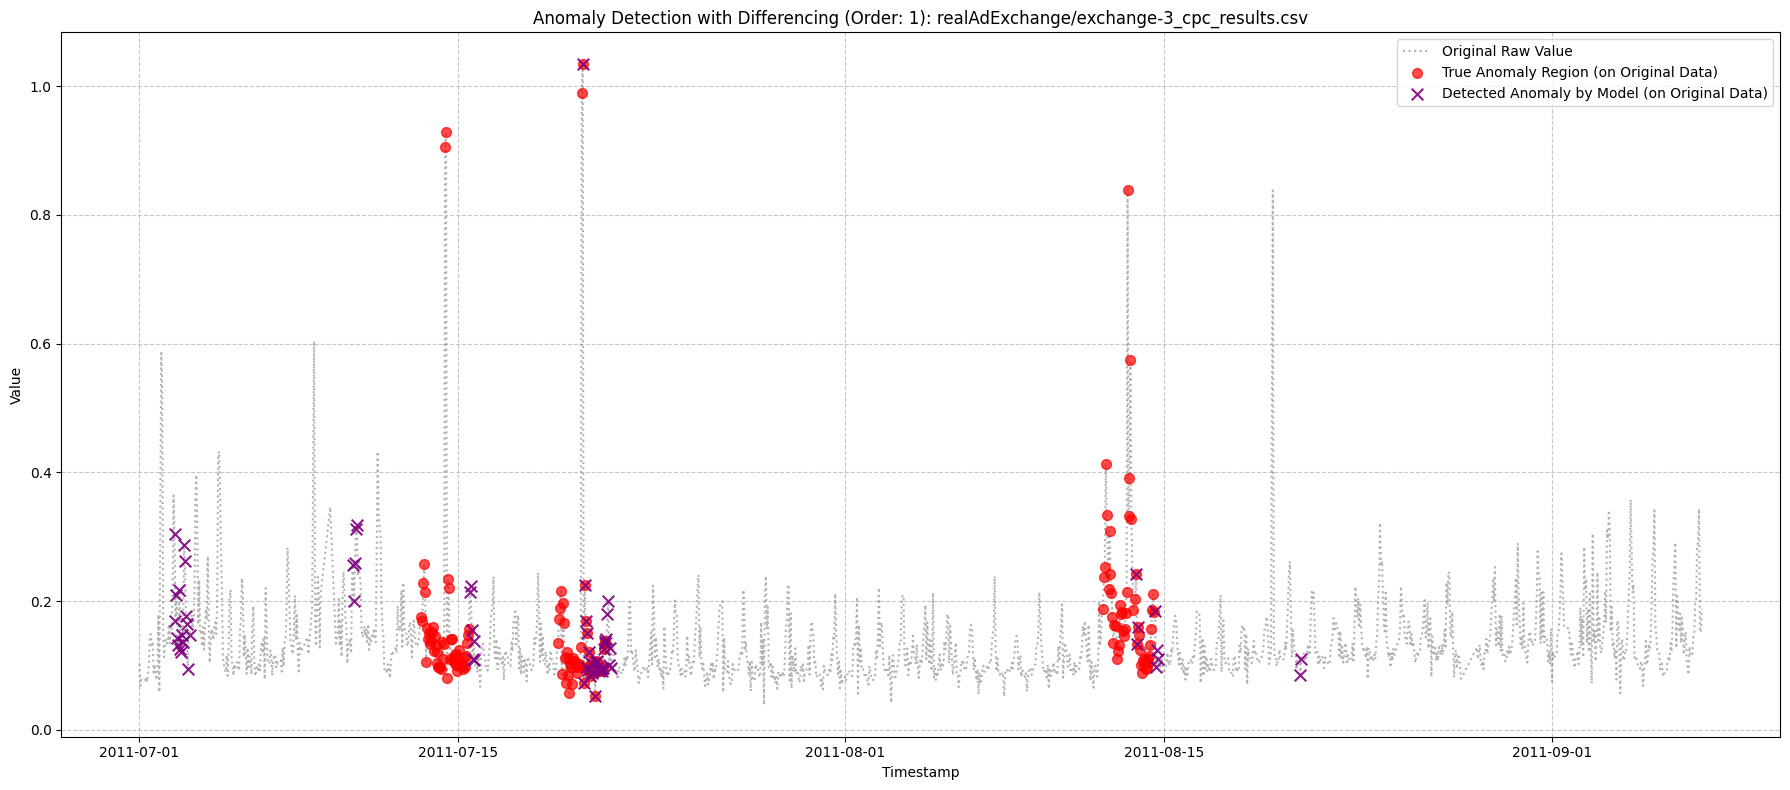

--- Visualization (with Differencing Preprocessing) Complete ---


In [21]:
print(f"\n--- Final Visualization (with Differencing Preprocessing) ---")
if ('data_df' in locals() and data_df is not None and
    'series_diff_processed' in locals() and series_diff_processed is not None and not series_diff_processed.empty and # <<< 修改在这里：去掉 .empty 后面的括号
    'anomaly_scores_diff' in locals() and anomaly_scores_diff is not None and
    'threshold_diff' in locals() and # 确保 threshold_diff 也已定义
    'processed_series_index' in locals() and processed_series_index is not None and
    'true_labels_for_evaluation_aligned' in locals() and true_labels_for_evaluation_aligned is not None):

    # ... (单元格 8 中后续的绘图代码保持不变) ...
    plt.figure(figsize=(18, 8))

    # 1. 绘制原始数据
    plt.plot(data_df.index, data_df['value'], label='Original Raw Value', color='gray', alpha=0.6, linestyle=':')

    # 2. (可选) 绘制差分后的数据
    # (这部分代码我之前提供了，如果需要可以取消注释并确保 ax1, ax2 正确设置)
    # fig = plt.gcf() # 获取当前图像
    # ax1 = plt.gca() # 获取当前坐标轴
    # ax2 = ax1.twinx()
    # ax2.plot(series_diff_processed.index, series_diff_processed, label=f'{DIFFERENCING_ORDER}-Order Differenced', color='green', linewidth=1.0, alpha=0.7)
    # ax2.set_ylabel(f'{DIFFERENCING_ORDER}-Order Differenced Value', color='green')
    # ax2.tick_params(axis='y', labelcolor='green')
    # # 合并图例 (如果用了双Y轴)
    # lines, labels = ax1.get_legend_handles_labels()
    # lines2, labels2 = ax2.get_legend_handles_labels()
    # ax2.legend(lines + lines2, labels + labels2, loc='best')


    # 3. 标记真实异常区域 (基于原始 data_df 的 is_anomaly)
    true_anomalies_plot_df = data_df[data_df['is_anomaly'] == 1]
    if not true_anomalies_plot_df.empty: # 这里也确保使用 .empty 而不是 .empty()
        plt.scatter(true_anomalies_plot_df.index,
                    true_anomalies_plot_df['value'],
                    color='red', label='True Anomaly Region (on Original Data)', marker='o', s=50, alpha=0.7, zorder=3)

    # 4. 标记模型检测到的异常点
    predicted_anomalies_on_diff_timeline = np.zeros_like(anomaly_scores_diff, dtype=int)
    if 'predicted_anomalies_bool_diff' in locals() and 'valid_indices_for_eval_diff' in locals():
        predicted_anomalies_on_diff_timeline[valid_indices_for_eval_diff] = predicted_anomalies_bool_diff.astype(int)

    detected_anomaly_timestamps_diff = pd.DatetimeIndex([]) # 初始化为空
    if len(predicted_anomalies_on_diff_timeline) == len(processed_series_index):
         detected_anomaly_timestamps_diff = processed_series_index[predicted_anomalies_on_diff_timeline == 1]
    elif len(predicted_anomalies_on_diff_timeline) > len(processed_series_index) and len(processed_series_index) > 0 :
         start_offset = len(predicted_anomalies_on_diff_timeline) - len(processed_series_index)
         # 确保布尔索引长度与 processed_series_index 匹配
         relevant_predictions = predicted_anomalies_on_diff_timeline[start_offset:]
         if len(relevant_predictions) == len(processed_series_index):
             detected_anomaly_timestamps_diff = processed_series_index[relevant_predictions == 1]
         else:
             print("Warning: Prediction and index length mismatch in visualization.")


    if not detected_anomaly_timestamps_diff.empty: # 这里也确保使用 .empty
        values_at_detected_anomalies_diff = data_df['value'].loc[detected_anomaly_timestamps_diff]
        plt.scatter(detected_anomaly_timestamps_diff,
                    values_at_detected_anomalies_diff,
                    color='purple', label='Detected Anomaly by Model (on Original Data)', marker='x', s=70, alpha=0.9, zorder=4)

    # 确保 DIFFERENCING_ORDER 和 JSON_KEY_FOR_LABELS 已定义
    title_diff_order = locals().get('DIFFERENCING_ORDER', 'N/A')
    title_json_key = locals().get('JSON_KEY_FOR_LABELS', 'N/A')
    plt.title(f"Anomaly Detection with Differencing (Order: {title_diff_order}): {title_json_key}")

    plt.xlabel("Timestamp")
    # 如果 ax1 和 ax2 都用了，主Y轴标签应与 ax1 匹配
    # if 'ax1' in locals():
    #     ax1.set_ylabel("Value")
    # else:
    plt.ylabel("Value")

    # 如果没有用双Y轴，可以直接plt.legend()
    # if 'ax1' not in locals() or 'ax2' not in locals() :
    plt.legend(loc='best')

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping final visualization as prerequisites are not met or differenced series was empty.")
print(f"--- Visualization (with Differencing Preprocessing) Complete ---")